In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/processed/featured_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

df = df.set_index("timestamp")

print("[INFO] Dataset loaded:", df.shape)
df.head()


[INFO] Dataset loaded: (43657, 18)


,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,load_lag_1,load_lag_24,load_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
timestamp,,,,,,,,,,,,,,,,,,
2015-01-07 23:00:00,28222.0,2.2,32,-12.6,52.0,1015.0,23,2,1,0,-0.258819,0.965926,31404.0,25555.0,22734.0,31718.583333,5933.401136,27376.958333
2015-01-08 00:00:00,25790.0,0.8,28,-15.6,43.0,1235.0,0,3,1,0,0.000000,1.000000,28222.0,23341.0,22734.0,31820.625000,5802.679387,27395.148810
2015-01-08 01:00:00,24481.0,-0.6,25,-18.0,36.0,1443.0,1,3,1,0,0.258819,0.965926,25790.0,22029.0,22734.0,31922.791667,5642.149945,27405.547619
2015-01-08 02:00:00,23883.0,-2.5,27,-19.2,36.0,1579.0,2,3,1,0,0.500000,0.866025,24481.0,21456.0,21286.0,32023.916667,5465.376314,27421.005952
2015-01-08 03:00:00,23761.0,-3.5,29,-19.2,36.0,1692.0,3,3,1,0,0.707107,0.707107,23883.0,21457.0,20264.0,32119.916667,5289.089097,27441.821429


In [3]:
y = df["load_actual"]

split_idx = int(len(y) * 0.8)

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


In [4]:
# ARIMA is used as a statistical baseline (univariate)
order = (5, 1, 3)

arima = ARIMA(y_train, order=order)
arima_fit = arima.fit()

print(arima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:            load_actual   No. Observations:                34925
Model:                 ARIMA(5, 1, 3)   Log Likelihood             -284093.855
Date:                Sat, 03 Jan 2026   AIC                         568205.710
Time:                        00:45:42   BIC                         568281.858
Sample:                    01-07-2015   HQIC                        568229.968
                         - 01-02-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0958      0.383      2.862      0.004       0.345       1.846
ar.L2         -0.0819      0.618     -0.132      0.895      -1.294       1.130
ar.L3         -0.0336      0.313     -0.107      0.9

In [5]:
n_test = len(y_test)

pred_arima = arima_fit.forecast(steps=n_test)
pred_arima = np.array(pred_arima)

mae_arima  = mean_absolute_error(y_test, pred_arima)
rmse_arima = mean_squared_error(y_test, pred_arima) ** 0.5
mape_arima = np.mean(np.abs((y_test - pred_arima) / y_test)) * 100

print("ARIMA Results")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)


ARIMA Results
MAE : 5284.485488688479
RMSE: 6500.768777625186
MAPE: 17.05299881346986


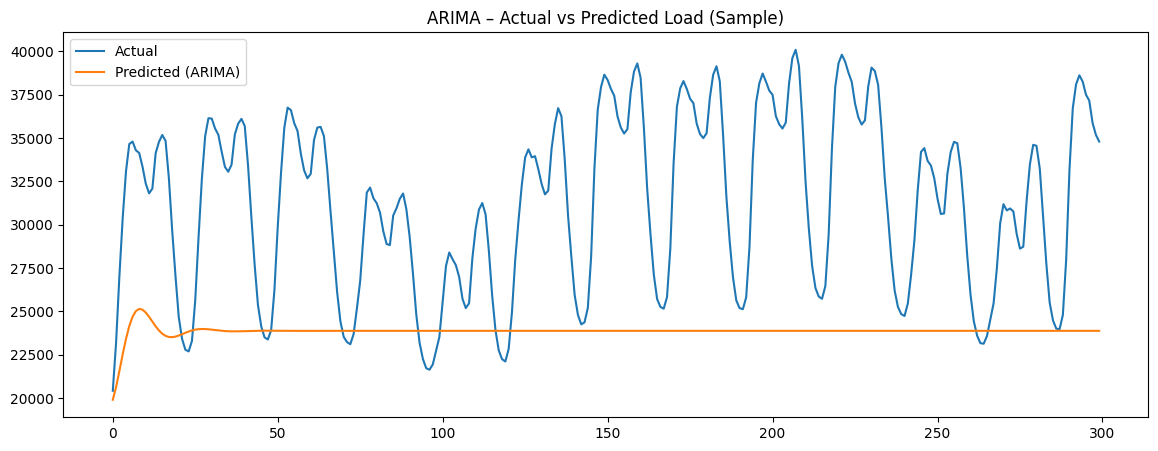

In [6]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(pred_arima[:300], label="Predicted (ARIMA)")
plt.legend()
plt.title("ARIMA – Actual vs Predicted Load (Sample)")
plt.show()


In [7]:
joblib.dump(arima_fit, "../saved_models/arima_model.pkl")

print("[INFO] ARIMA model saved")


[INFO] ARIMA model saved
